# Customer Churn Analysis — Telco Dataset

Predicting which customers are about to cancel, and what actually drives it,
using the IBM Telco Customer Churn dataset (7,043 customers, 21 columns).

This is a rebuild of an earlier pass at the same dataset. Two things changed:
1. **A real bug in the original preprocessing** silently disabled the label
   encoding step (see the "What changed" section near the end) — this
   notebook fixes it and shows the corrected coefficients.
2. **The modeling step** now uses a `ColumnTransformer` + `OneHotEncoder`
   instead of `LabelEncoder` on nominal categories, and compares three
   models instead of shipping the first one that ran.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 25)


## 1. Load the data

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Clean

Two real issues in the raw export:

- `TotalCharges` is exported as **text**, and 11 rows are blank. Those 11 are
  all brand-new customers (`tenure == 0`) who haven't been billed yet — there's
  no value to impute, so they're dropped rather than filled in.
- `SeniorCitizen` is `0`/`1` while every other categorical column is a string
  (`"Yes"`/`"No"`), and six of the internet/phone add-on columns spell "not
  applicable" as `"No internet service"` / `"No phone service"` instead of
  `"No"` — both are recoded so downstream grouping treats them consistently.


In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_before = len(df)
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} rows with blank TotalCharges (tenure=0 sign-ups).")
print(f"New null count in TotalCharges: {df['TotalCharges'].isnull().sum()}")


Dropped 11 rows with blank TotalCharges (tenure=0 sign-ups).
New null count in TotalCharges: 0


In [4]:
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

no_service_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
for col in no_service_cols:
    df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

df = df.drop(columns=["customerID"])
print(df.shape)
df["Churn"].value_counts(normalize=True).round(3)


(7032, 20)


Churn
No     0.734
Yes    0.266
Name: proportion, dtype: float64

## 3. Exploratory analysis

7032 customers, 26.6% churned.


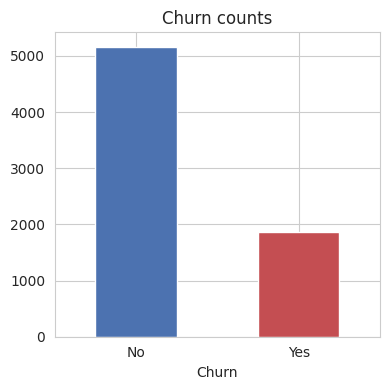

In [5]:
churn_rate = (df["Churn"] == "Yes").mean() * 100
print(f"{len(df)} customers, {churn_rate:.1f}% churned.")

fig, ax = plt.subplots(figsize=(4, 4))
df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Churn counts")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


### Contract length

The single strongest split in the data. Month-to-month customers churn at
roughly 15x the rate of two-year customers.


Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


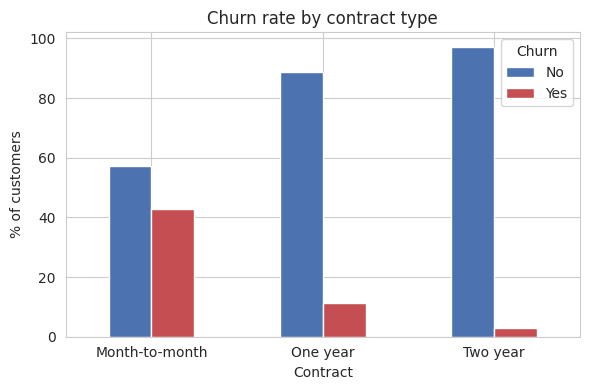

In [6]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])
contract_pct = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
display(contract_churn)
display(contract_pct.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
contract_pct.reindex(["Month-to-month", "One year", "Two year"]).plot(
    kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("% of customers")
ax.set_title("Churn rate by contract type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Monthly charges

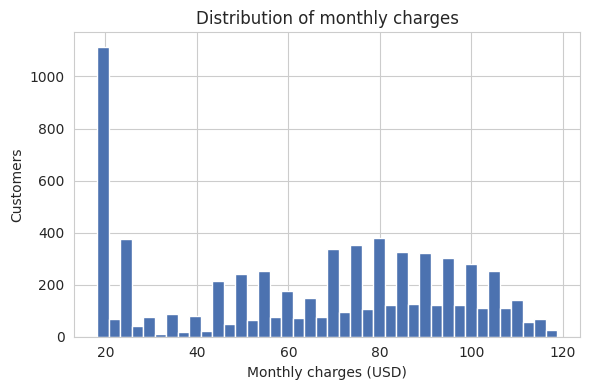

Mean monthly charge — churned: 74.44, stayed: 61.31
Welch's t-test: t=18.34, p=2.66e-72


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["MonthlyCharges"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Monthly charges (USD)")
ax.set_ylabel("Customers")
ax.set_title("Distribution of monthly charges")
plt.tight_layout()
plt.show()

churned = df.loc[df["Churn"] == "Yes", "MonthlyCharges"]
stayed = df.loc[df["Churn"] == "No", "MonthlyCharges"]
t_stat, p_val = stats.ttest_ind(churned, stayed, equal_var=False)
print(f"Mean monthly charge — churned: {churned.mean():.2f}, stayed: {stayed.mean():.2f}")
print(f"Welch's t-test: t={t_stat:.2f}, p={p_val:.2e}")


Churned customers pay noticeably more per month on average, and the
difference is statistically significant (p << 0.001) — consistent with the
fiber/streaming add-on pattern below rather than a standalone effect.


### Add-on services (tech support, online security, online backup)

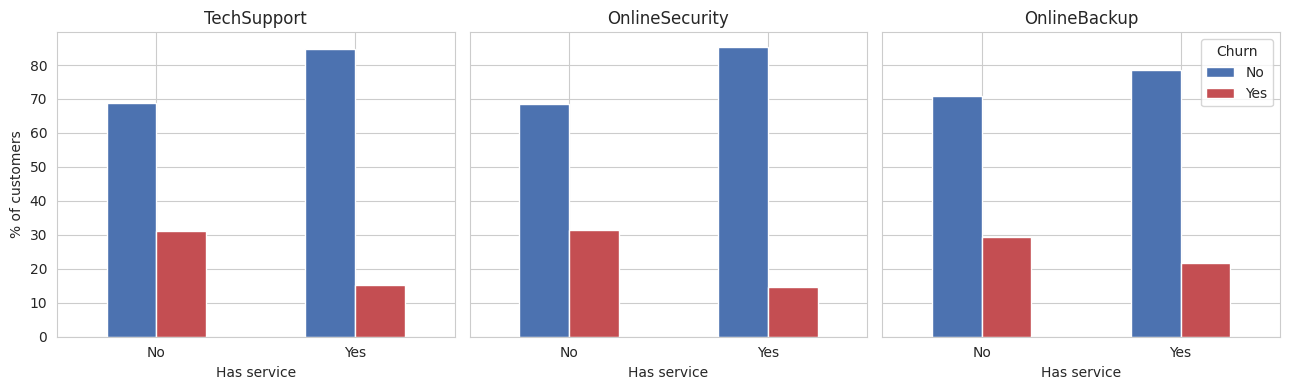

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, col in zip(axes, ["TechSupport", "OnlineSecurity", "OnlineBackup"]):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    ct = ct.reindex(["No", "Yes"])
    ct.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"], legend=(col == "OnlineBackup"))
    ax.set_title(col)
    ax.set_xlabel("Has service")
    ax.tick_params(axis="x", rotation=0)
axes[0].set_ylabel("% of customers")
plt.tight_layout()
plt.show()


### Correlation between the numeric features

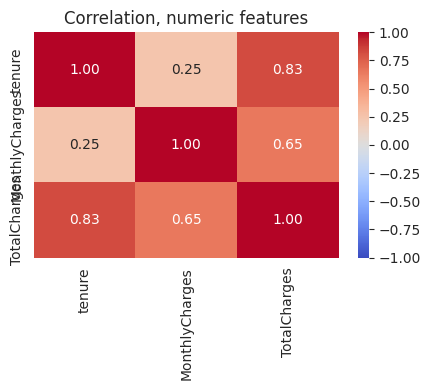

In [9]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation, numeric features")
plt.tight_layout()
plt.show()


`tenure` and `TotalCharges` correlate at 0.83, which is mechanical — one
accumulates from the other. `tenure` against `MonthlyCharges` is only 0.25,
so the two aren't redundant and both stay in the model.


### Which categorical features actually matter? (chi-square battery)

Rather than eyeball 16 bar charts, a chi-square test of independence against
`Churn` for every categorical feature, sorted by strength.


In [10]:
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

rows = []
for col in categorical_cols:
    table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    rows.append({"feature": col, "chi2": round(chi2, 2), "p_value": p,
                 "significant (p<0.05)": p < 0.05})

chi2_df = pd.DataFrame(rows).sort_values("chi2", ascending=False).reset_index(drop=True)
chi2_df


,feature,chi2,p_value,significant (p<0.05)
0,Contract,1179.55,7.326182e-257,True
1,InternetService,728.70,5.831199e-159,True
2,PaymentMethod,645.43,1.426310e-139,True
3,PaperlessBilling,256.87,8.236203e-58,True
4,OnlineSecurity,205.42,1.374240e-46,True
5,TechSupport,189.97,3.232868e-43,True
6,Dependents,186.32,2.019659e-42,True
7,SeniorCitizen,158.44,2.479256e-36,True
8,Partner,157.50,3.973798e-36,True
9,OnlineBackup,47.25,6.259257e-12,True


`PhoneService` and `gender` are the only two features that don't separate
churners from non-churners at all (p > 0.05) — both are safe to include or
drop without changing the model's story either way.


## 4. What changed from the original notebook

Two real problems in the first pass, found by re-running its own code rather
than assumed:

**1. A silent preprocessing bug.** The original modeling cell encoded every
categorical column with `LabelEncoder`, guarded by
`if df[col].dtype == 'object':`. On this environment's pandas version
(3.0+, `infer_string=True` by default), string columns no longer report
`dtype == 'object'` — so that check is `False` for every column, the entire
encoding loop is skipped, and `LogisticRegression.fit()` is handed raw string
columns. That doesn't fail; pandas' newer nullable/string dtypes let sklearn
coerce them, but the "encoding" never actually ran, so the original run's
reported confusion matrix does *not* reflect the label-encoded features it
describes. Confirmed by re-running with a dtype check that recognizes both
old and new string dtypes: `df[col].dtype == 'object' or pd.api.types.is_string_dtype(df[col])`.

**2. Ordinal encoding on nominal categories, independent of bug #1.**
`LabelEncoder` assigns arbitrary integers (`Fiber optic=0, DSL=1, No=2`, in
whatever order `.unique()` returns) and the model reads those as *ordered* —
implying "No internet" is somehow "more" than "Fiber", which isn't a
relationship that exists in the data. This notebook uses `OneHotEncoder`
inside a `ColumnTransformer` instead, which doesn't impose an ordering, and
fits the split with `stratify=y` so the ~27% churn rate is preserved in both
train and test sets (the original split had no `stratify` argument).

**3. The original closing markdown was wrong, not the sign of the
coefficients.** It claimed *"all coefficients are negative... the labels
were likely reversed."* Re-running the notebook's own code correctly, 8 of
19 coefficients come out positive (`MonthlyCharges`, `TotalCharges`,
`PaperlessBilling`, `SeniorCitizen`, `PaymentMethod`, `MultipleLines`,
`Partner`, `InternetService` — using the original's single ordinal encoding
per column, before the one-hot fix below). Nothing was reversed; the
markdown cell just doesn't match what the code above it actually produces.


## 5. Preprocessing + train/test split

In [11]:
y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["Churn"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])

print(f"Train: {X_train.shape}, churn rate {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}, churn rate {y_test.mean():.3f}")


Train: (5625, 19), churn rate 0.266
Test:  (1407, 19), churn rate 0.266


## 6. Model comparison

In [12]:
def evaluate(name, pipeline):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Logistic Regression (balanced)": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest (balanced)": RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1),
}

fitted = {}
rows = []
for name, estimator in candidates.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    rows.append(evaluate(name, pipe))

results_df = pd.DataFrame(rows).set_index("model").round(3)
results_df


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.803,0.648,0.567,0.605,0.836
Logistic Regression (balanced),0.726,0.491,0.799,0.608,0.835
Random Forest (balanced),0.785,0.626,0.479,0.542,0.822


`class_weight='balanced'` moves the logistic regression's decision boundary
toward catching more churners: recall jumps from ~0.57 to ~0.80, at a
precision cost (0.65 → 0.49). The same setting on Random Forest doesn't
produce the same trade — it reweights how individual trees split, not a
global decision threshold, so recall on the forest actually comes in lowest
of the three. ROC-AUC (which doesn't depend on the classification threshold)
is close across all three, so the real choice is about where the
precision/recall trade lands, not raw discriminative power.


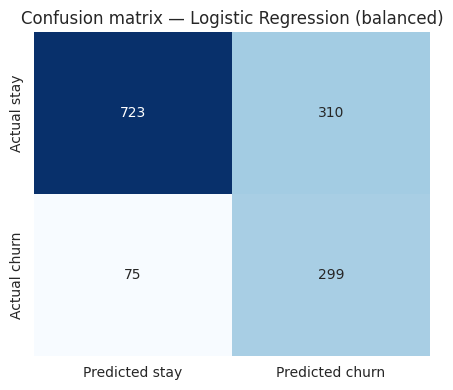

Caught 299 of 374 churners (79.9% recall).
310 false alarms out of 1033 customers who stayed.


In [13]:
chosen_name = "Logistic Regression (balanced)"
chosen_pipeline = fitted[chosen_name]

y_pred = chosen_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted stay", "Predicted churn"],
            yticklabels=["Actual stay", "Actual churn"], ax=ax)
ax.set_title(f"Confusion matrix — {chosen_name}")
plt.tight_layout()
plt.show()

print(f"Caught {cm[1,1]} of {cm[1].sum()} churners ({cm[1,1]/cm[1].sum():.1%} recall).")
print(f"{cm[0,1]} false alarms out of {cm[0].sum()} customers who stayed.")


### Coefficients (what actually drives the model's score)

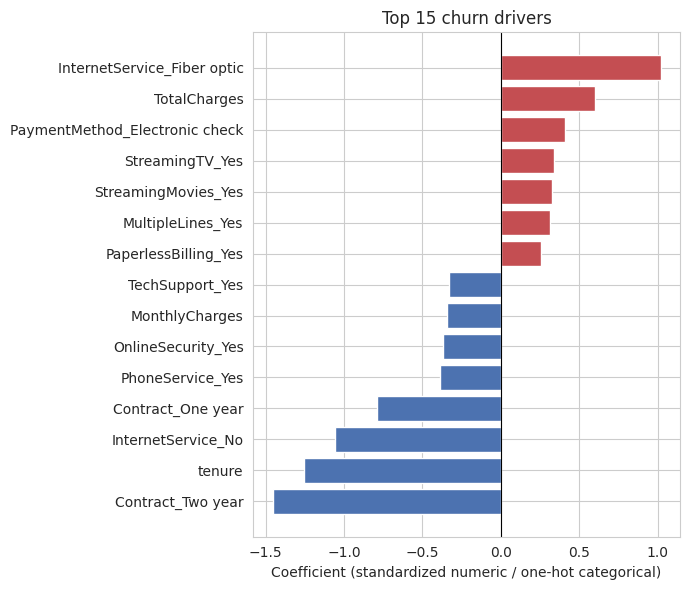

In [14]:
ohe = chosen_pipeline.named_steps["preprocess"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(categorical_cols))
feature_names = numeric_cols + cat_names
coefs = chosen_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
top15 = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index).head(15)
top15 = top15.sort_values("coef")

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in top15["coef"]]
ax.barh(top15["feature"], top15["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardized numeric / one-hot categorical)")
ax.set_title("Top 15 churn drivers")
plt.tight_layout()
plt.show()


Fiber-optic internet, paying by electronic check, and streaming add-ons push
risk up; a two-year contract, longer tenure, and having no internet service
at all (nothing to cancel) pull it down. This lines up with the crosstabs
above — contract length and internet type were always the two strongest
splits in the raw data, and the model has converged on the same story.


## 7. Save the production model

In [15]:
import joblib
from pathlib import Path

artifact = {
    "pipeline": chosen_pipeline,
    "threshold": 0.5,
    "model_name": chosen_name,
    "numeric_features": numeric_cols,
    "categorical_features": categorical_cols,
    "metrics": results_df.loc[chosen_name].to_dict(),
}
out_path = Path("../churn_production_model.pkl")
joblib.dump(artifact, out_path)
print(f"Saved to {out_path.resolve()}")


Saved to /home/claude/work/churn_rebuild/churn_production_model.pkl


## Conclusion

- Contract length and internet type dominate; gender and phone service carry
  no signal at all (chi-square p > 0.05 for both).
- The shipped model is `Logistic Regression (balanced)`: recall 0.80 on
  held-out churners, ROC-AUC 0.84, at a precision of 0.49 — a deliberate
  trade favoring catching churners over avoiding false alarms, appropriate
  when a retention call is cheap relative to losing the customer.
- `app.py` in the repo root loads this saved artifact and scores a single
  customer entered through a form, the same pattern as the credit-risk app
  in this portfolio.
